In [526]:
import duckdb
import pandas as pd
import seaborn as sns
from pprint import pprint

In [527]:
con = duckdb.connect("/home/etienne/projects/inatML/data/raw/raw.duckdb")
df = con.execute("SELECT * FROM downloads").df()
con.close()

In [528]:
def plot_obs_dist(df1, df2, col = 'user_id'):
    df_plots = pd.merge(df1, df2, on=col, how='inner')
    sns.displot(df_plots, x = 'observed_on', kind='kde', hue='user_id',legend=False)

def plot_quality_dist(df1, df2, col = 'user_id'):
    df_plots = pd.merge(df1, df2, on=col, how='inner')
    sns.histplot(df_plots,x = 'quality_grade', stat ='percent', legend= True)

In [ ]:
print_df_user_stats = lambda df: print( "Total observations:", df['obs_count'].sum(), "\nTotal users:", df.shape[0]) 

In [530]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549770 entries, 0 to 549769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             549770 non-null  int64         
 1   uuid                           549770 non-null  str           
 2   observed_on_string             548804 non-null  str           
 3   observed_on                    548802 non-null  datetime64[us]
 4   time_observed_at               542313 non-null  str           
 5   time_zone                      549734 non-null  str           
 6   user_id                        549770 non-null  int64         
 7   created_at                     549770 non-null  str           
 8   updated_at                     549770 non-null  str           
 9   quality_grade                  549770 non-null  str           
 10  license                        439692 non-null  str           
 11  url        

In [531]:
#Clean df
before = df.shape[0]
#Drop columns with all na
df = df.drop(columns=['time_observed_at', 'license', 'time_zone'])

#Drop rows with na
df = df.dropna(subset=['observed_on'])

print(f"Removed {before - df.shape[0]}")
df.info()

Removed 968
<class 'pandas.DataFrame'>
Index: 548802 entries, 0 to 549769
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             548802 non-null  int64         
 1   uuid                           548802 non-null  str           
 2   observed_on_string             548802 non-null  str           
 3   observed_on                    548802 non-null  datetime64[us]
 4   user_id                        548802 non-null  int64         
 5   created_at                     548802 non-null  str           
 6   updated_at                     548802 non-null  str           
 7   quality_grade                  548802 non-null  str           
 8   url                            548802 non-null  str           
 9   num_identification_agreements  548802 non-null  int64         
 10  taxon_id                       548802 non-null  int64         
dtypes: d

In [532]:
#Add year and month column from observed_on
df['year'] = df['observed_on'].dt.year.astype(int).rename('year')
df['month'] = df['observed_on'].dt.month.astype(int).rename('month')
df.head()

,id,uuid,observed_on_string,observed_on,user_id,created_at,updated_at,quality_grade,url,num_identification_agreements,taxon_id,year,month
0,18461,4fd58d7d-b160-4891-ac0b-3fc99896dd19,"May 20, 2011 10:00",2011-05-20,1427,2011-05-27 02:29:40 +0000,2023-07-06 15:08:43 +0000,casual,http://www.inaturalist.org/observations/18461,1,56136,2011,5
1,18485,bf9bd91c-dba7-420b-a0b8-605519ba188f,2011-05-20,2011-05-20,1427,2011-05-27 05:30:31 +0000,2024-01-17 16:40:37 +0000,casual,http://www.inaturalist.org/observations/18485,3,68884,2011,5
2,18486,b223b0ac-f407-4a30-b07e-8fb6a687d4f1,"May 20, 2011 10:00",2011-05-20,1427,2011-05-27 05:32:57 +0000,2023-07-06 15:08:47 +0000,research,http://www.inaturalist.org/observations/18486,2,55828,2011,5
3,24637,bf75d1c8-d2e2-4905-9191-54079515b018,2011-06-19,2011-06-19,2179,2011-07-12 16:43:27 +0000,2024-07-09 18:23:47 +0000,research,http://www.inaturalist.org/observations/24637,5,48726,2011,6
5,145027,7cb27e42-148f-48cd-a839-8c08713142a1,"November 1, 2012 11:12:00 AM GMT",2012-11-01,10763,2012-11-08 07:50:05 +0000,2019-10-25 20:46:18 +0000,casual,http://www.inaturalist.org/observations/145027,0,47125,2012,11


In [533]:
#Remove old observations
before = '2010-01-01'
raw_count = df.shape[0]
df = df[df['observed_on'] >= before]
print(f'Removing outliers before {before} -> Removed', raw_count - df.shape[0], 'observations')


Removing outliers before 2010-01-01 -> Removed 1237 observations


In [534]:
#Observation count filter

threshold = 20

unique_users =  df['user_id'].nunique()
df_user = df.groupby(by ='user_id').count().reset_index('user_id')
df_user = df_user[['user_id', 'id']].rename(columns={'id': 'obs_count'})
df_user.sort_values(by='obs_count', inplace=True, ascending= False)
df_user = df_user[df_user['obs_count'] >= threshold]

print("Unique users:", unique_users)
print_df_user_stats(df_user)

Unique users: 26800
Total observations: 438982 
Total users: 3371


In [535]:
#Temporal filter
old_threshold = '2020-01-01'
new_threshold = '2024-01-01'
df_temporal = pd.merge(df, df_user, on=['user_id'], how='inner')

min = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').min().reset_index('user_id').rename(columns={'observed_on' : 'oldest'})
max = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').max().reset_index('user_id').rename(columns={'observed_on' : 'newest'})
df_user = pd. merge(df_user, min, on=['user_id'], how='inner')
df_user = pd. merge(df_user, max, on=['user_id'], how='inner')


df_user = df_user[df_user['oldest'] <= old_threshold]
print("-User with obs older than 2018-")
print_df_user_stats(df_user)

df_user = df_user[df_user['newest'] >= new_threshold]
print("-User with last obs at least in last 2 years-")
print_df_user_stats(df_user)



-User with obs older than 2018-
Total observations: 212244 
Total users: 681
-User with last obs at least in last 2 years-
Total observations: 199032 
Total users: 459


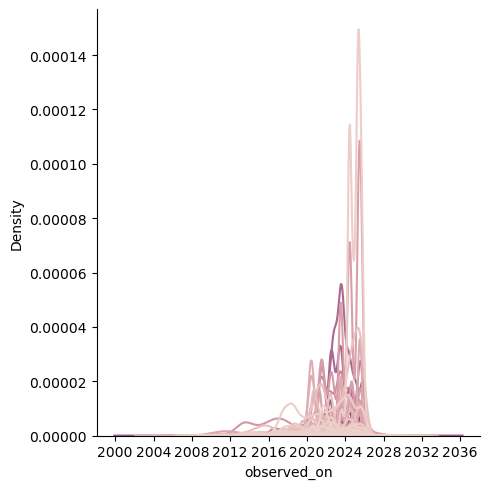

In [536]:
plot_obs_dist(df_user, df)


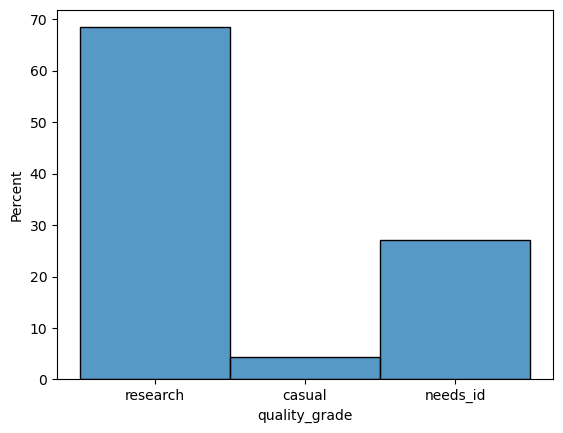

In [537]:
plot_quality_dist(df_user, df)

In [538]:
#Set half of data from maximum lower user sort 
target = 20000
df_user_low = df_user.sort_values('obs_count')
df_user_low

low_users =[]
count = 0

for index, row in df_user_low.iterrows():
    if count > target:
        break

    low_users.append(row['user_id'])
    count += row['obs_count']



df_user_low = df_user[df_user['user_id'].isin(low_users)]
print_df_user_stats(df_user_low)
print(df_user_low['obs_count'].mean())
print(len(low_users))

Total observations: 20123 
Total users: 292
68.91438356164383
292


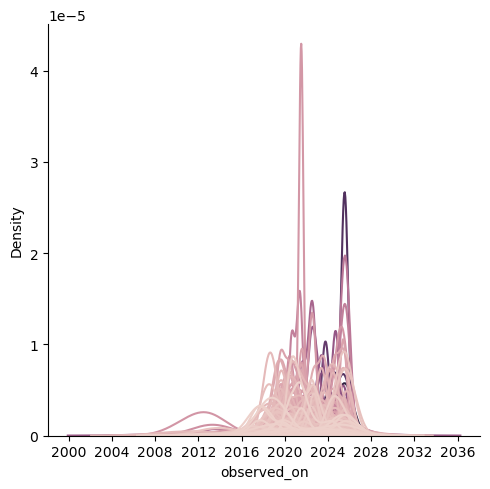

In [539]:
plot_obs_dist(df_user_low, df)


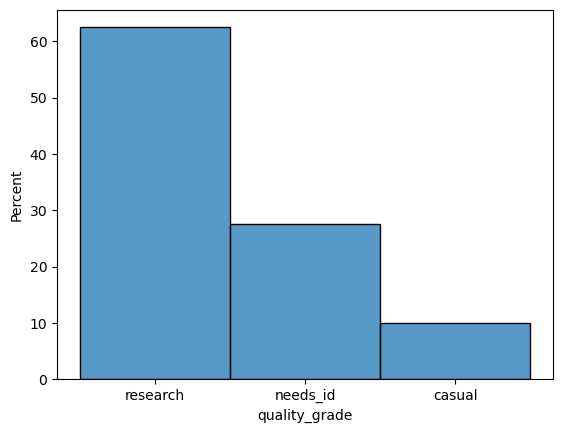

In [540]:
plot_quality_dist(df_user_low, df)

<Axes: xlabel='obs_count'>

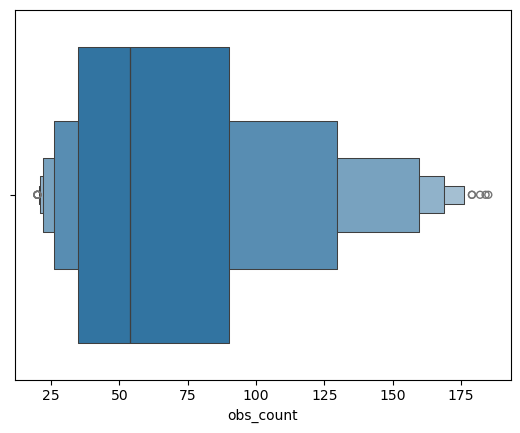

In [541]:
sns.boxenplot(df_user_low, x ='obs_count')

In [542]:
df_user_high = df_user[~df_user['user_id'].isin(low_users)]
df_user_high_obs = pd.merge(df, df_user_high, on=['user_id'], how='inner')
total = df_user_high_obs['id'].nunique()
split_percentage = target / total
print_df_user_stats(df_user_high)
print(total)
print(split_percentage)

Total observations: 178909 
Total users: 167
178907
0.11178992437411617


In [604]:
# Create stratified col
df_user_high_obs['combined_col'] = df_user_high_obs['user_id'].astype(str) + "_" + df['quality_grade'].astype(str)
df_user_high_obs.dropna(inplace = True)
df_user_high_obs.shape[0]

177845

In [609]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df_user_high_obs, test_size=split_percentage,shuffle=True, stratify=df_user_high_obs['combined_col'], random_state=43)
df_test.shape[0]

x = df_test['uuid'].to_list()
pprint(x[:10])


['886f032e-7fa8-44ef-bd9c-826597a6ce3c',
 '7a61472f-9828-436e-a6b0-4b93e79fc66d',
 '0f0e9fab-0477-480d-ad45-72db63806d48',
 '43ab2dd1-12ab-4722-a1a7-1b44780ead90',
 'ab04b53d-4656-4653-a763-11981ddcb312',
 '22e7add9-d886-4e00-8cc9-2b341ae81aaf',
 '60a6b4f1-db82-4f7d-8de0-07a8d8c5419e',
 '6ee8ec42-f924-4707-a7a9-eedb2f30973e',
 'b10af847-a156-4a01-842c-6fae691f6cad',
 '2f1f05eb-642a-44d3-9663-55f2a6ce9867']


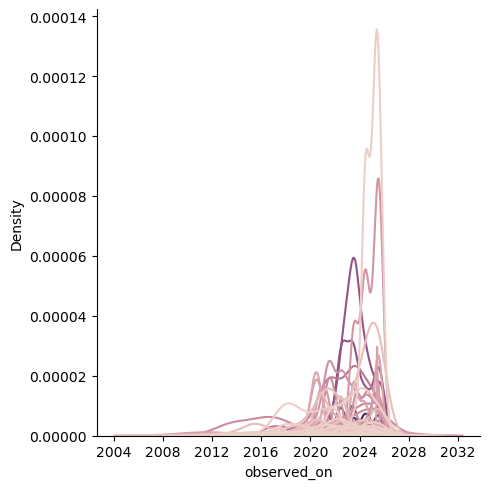

In [606]:
sns.displot(df_test, x = 'observed_on', kind ='kde', hue ='user_id', legend=False)

<Axes: xlabel='quality_grade', ylabel='Percent'>

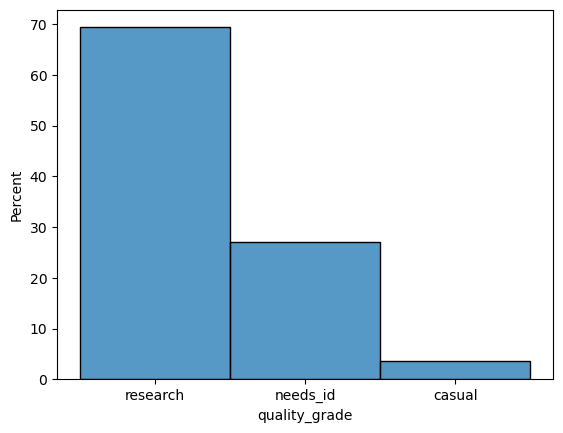

In [607]:
sns.histplot(df_test,x = 'quality_grade', stat ='percent', legend= True)

In [ ]:
"""
df_monthly_obs = pd.merge(df, df_user, on='user_id', how='inner')
df_grouped = df.groupby(['user_id', df['observed_on'].dt.year.rename('year'), df['observed_on'].dt.month.rename('month')])['id'].count().reset_index('user_id', name ='count')
df_grouped.reset_index('year', inplace=True)
df_grouped.reset_index('month', inplace=True)
df_grouped = df_grouped[df_grouped['year'] <= 2020 ]
df_grouped
g = sns.relplot(data=df_grouped, x ='month', y='count', col= 'year', hue = 'user_id', col_wrap= 3, legend = False)
"""


"\ndf_monthly_obs = pd.merge(df, df_user, on='user_id', how='inner')\ndf_grouped = df.groupby(['user_id', df['observed_on'].dt.year.rename('year'), df['observed_on'].dt.month.rename('month')])['id'].count().reset_index('user_id', name ='count')\ndf_grouped.reset_index('year', inplace=True)\ndf_grouped.reset_index('month', inplace=True)\ndf_grouped = df_grouped[df_grouped['year'] <= 2020 ]\ndf_grouped\ng = sns.relplot(data=df_grouped, x ='month', y='count', col= 'year', hue = 'user_id', col_wrap= 3, legend = False)\n"